# Analyze 10x Atera (WTA Preview) FFPE breast cancer data

Atera is 10x Genomics' next-generation, in-situ, whole-transcriptome assay built on top of the Xenium platform. Compared with Xenium's gene-panel chemistry, Atera v1 expands coverage to ~18,000 human gene targets while keeping the cell-segmentation, polygon, and OME-TIFF morphology imaging that Xenium tutorials are written against.

An Atera `outs/` bundle ships **a Xenium-format core plus three additions**:

| File / folder | Origin | Notes |
|---|---|---|
| `cell_feature_matrix.h5` | shared | gene × cell sparse counts (10x HDF5) |
| `cells.parquet` | shared | per-cell metadata + centroids (microns) |
| `cell_boundaries.parquet` | shared | per-cell polygon vertices |
| `experiment.xenium` | shared | pipeline metadata (JSON) |
| **`nucleus_boundaries.parquet`** | Atera-only | per-cell nucleus polygon vertices |
| **`morphology_focus/ch####_<tag>.ome.tif`** | Atera-only | named multi-stain images (DAPI, ATP1A1+CD45+E-Cad, 18S, αSMA+Vim) |
| `*_cell_groups.csv` | optional | vendor-shipped cell-type classifier (cell_id → group → display color) |
| `*_he_image.ome.tif` + `*_he_alignment.csv` | optional | registered H&E whole-slide image and 3×3 affine |

OmicVerse's `ov.io.spatial.read_atera` mirrors `read_xenium` plus loaders for the four Atera-only items. This notebook walks through:

1. loading an Atera FFPE breast-cancer bundle into a single `AnnData`,
2. inspecting the four morphology stain channels,
3. plotting the vendor-supplied cell-type segmentation in spatial coords,
4. zooming into a small region with `ov.pl.spatialseg` to render cell polygons,
5. running standard preprocessing (filter, normalize, HVG, PCA),
6. plotting per-gene spatial expression for canonical breast-cancer markers.

## Environment setup

In [1]:
import omicverse as ov
ov.style(font_path='Arial')

%load_ext autoreload
%autoreload 2

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
ov.settings.cpu_gpu_mixed_init()

CPU-GPU mixed mode activated
Available GPU accelerators: CUDA


## Inspect the Atera bundle

Atera ships its primary outputs as a single `outs.zip`. For tutorials we extract the small files (matrices, parquet, JSON) plus the four morphology focus channels — the giant `morphology.ome.tif` (~15 GB, full multi-z stack) and `transcripts.parquet` (~10 GB) are not needed for cell-level downstream analysis.

Companion files (cell_groups CSV, H&E image + alignment CSV) sit *next to* `outs/` in the public 10x dataset page rather than inside it.

In [3]:
from pathlib import Path

ATERA = Path("data/atera_breast_cancer")

# Show top-level files + the morphology_focus channel TIFFs (skip GB-scale OME-TIFFs).
for p in sorted(ATERA.iterdir()):
    if p.is_dir():
        print(f"  {p.name}/")
        for k in sorted(p.iterdir()):
            print(f"      {k.name}  ({k.stat().st_size / 1024**2:,.1f} MB)")
    else:
        size_mb = p.stat().st_size / 1024**2
        # Skip the multi-GB H&E OME-TIFF and outs.zip from the printout.
        if size_mb < 500:
            print(f"  {p.name}  ({size_mb:,.1f} MB)")
        else:
            print(f"  {p.name}  ({size_mb / 1024:,.1f} GB)  # large, not loaded directly")


  WTA_Preview_FFPE_Breast_Cancer_cell_groups.csv  (7.2 MB)
  WTA_Preview_FFPE_Breast_Cancer_he_alignment.csv  (0.0 MB)
  WTA_Preview_FFPE_Breast_Cancer_he_image.ome.tif  (16.5 GB)  # large, not loaded directly
  WTA_Preview_FFPE_Breast_Cancer_keypoints.csv  (0.0 MB)
  WTA_Preview_FFPE_Breast_Cancer_outs.zip  (51.4 GB)  # large, not loaded directly
  analysis.tar.gz  (72.3 MB)
  atera_dapi.h5ad  (2.5 GB)  # large, not loaded directly
  cell_boundaries.parquet  (15.4 MB)
  cell_feature_matrix.h5  (379.7 MB)
  cells.parquet  (3.4 MB)
  experiment.xenium  (0.0 MB)
  metrics_summary.csv  (0.0 MB)
  morphology_focus/
      ch0000_dapi.ome.tif  (1,224.5 MB)
      ch0001_atp1a1_cd45_e-cadherin.ome.tif  (1,309.9 MB)
      ch0002_18s.ome.tif  (1,324.1 MB)
      ch0003_alphasma_vimentin.ome.tif  (1,169.8 MB)
  nucleus_boundaries.parquet  (14.1 MB)


## Load the dataset with `read_atera`

`read_atera` returns an `AnnData` with:

- **`X`**: cells × genes sparse counts (control probes / codewords are dropped automatically; only `Gene Expression` features are kept).
- **`obsm['spatial']`**: cell centroids in microns.
- **`obs`**: cells.parquet metadata, plus `geometry` (cell polygon WKT), `nucleus_geometry` (nucleus polygon WKT), and — when `cell_groups_csv` is passed — `cell_group` and `cell_group_color` columns from the vendor's classifier.
- **`uns['spatial'][library_id]`**: `images['hires']` (the chosen morphology channel), scalefactors that map microns → image pixels, and the full `experiment.xenium` metadata dict.

We start by selecting the `dapi` channel for the morphology image. Atera multi-channel selection accepts either a semantic tag (`'dapi'`, `'boundary'`, `'rna'`, `'stroma'`), a substring (`'cd45'`, `'18s'`), or an integer-as-string index (`'0'`–`'3'`).

In [4]:
adata = ov.io.spatial.read_atera(
    ATERA,
    image_key='dapi',
    image_max_dim=2048,
    cell_groups_csv=ATERA / 'WTA_Preview_FFPE_Breast_Cancer_cell_groups.csv',
    cache_file=ATERA / 'atera_dapi.h5ad',
)
adata

[Atera] Reading cached AnnData from: /scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/atera_breast_cancer/atera_dapi.h5ad


AnnData object with n_obs × n_vars = 170057 × 18028
    obs: 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'geometry', 'nucleus_geometry', 'cell_group', 'cell_group_color'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'omicverse_io', 'spatial'
    obsm: 'spatial'

[Atera] Loaded cell polygons for 170057/170057 cells


[Atera] Loaded nucleus polygons for 168335/170057 cells
[Atera] Merged cell_groups: 170057/170057 cells from WTA_Preview_FFPE_Breast_Cancer_cell_groups.csv


[Atera] Wrote cache AnnData to: /scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/atera_breast_cancer/atera_dapi.h5ad
[Atera] Done (n_obs=170057, n_vars=18028, library_id=WTA Breast Cancer (FFPE))


AnnData object with n_obs × n_vars = 170057 × 18028
    obs: 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'geometry', 'nucleus_geometry', 'cell_group', 'cell_group_color'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'omicverse_io'
    obsm: 'spatial'

The `experiment.xenium` metadata is preserved verbatim under `uns['spatial']['<library>']['metadata']`. The `pixel_size` field (in microns) defines how spatial centroids are converted into image-pixel coordinates downstream.

In [5]:
library_id = list(adata.uns['spatial'].keys())[0]
meta = adata.uns['spatial'][library_id]['metadata']
for k in ['run_name', 'region_name', 'preservation_method', 'panel_name',
          'panel_num_targets_predesigned', 'chemistry_version', 'pixel_size',
          'num_cells', 'transcripts_per_cell']:
    print(f"  {k:30s} {meta.get(k)}")

  run_name                       WTA Preview
  region_name                    WTA Breast Cancer (FFPE)
  preservation_method            FFPE
  panel_name                     Human WTA (pre-release)
  panel_num_targets_predesigned  18028
  chemistry_version              Atera v1
  pixel_size                     0.2125
  num_cells                      170057
  transcripts_per_cell           2116


## Quick QC: per-cell distributions

Atera's `cells.parquet` already carries per-cell `transcript_counts`, `cell_area`, and `nucleus_count`. A first sanity check is to verify the distributions look reasonable: a mean of ~2,000 transcripts/cell with cell areas in the tens of µm² is typical for Atera v1.

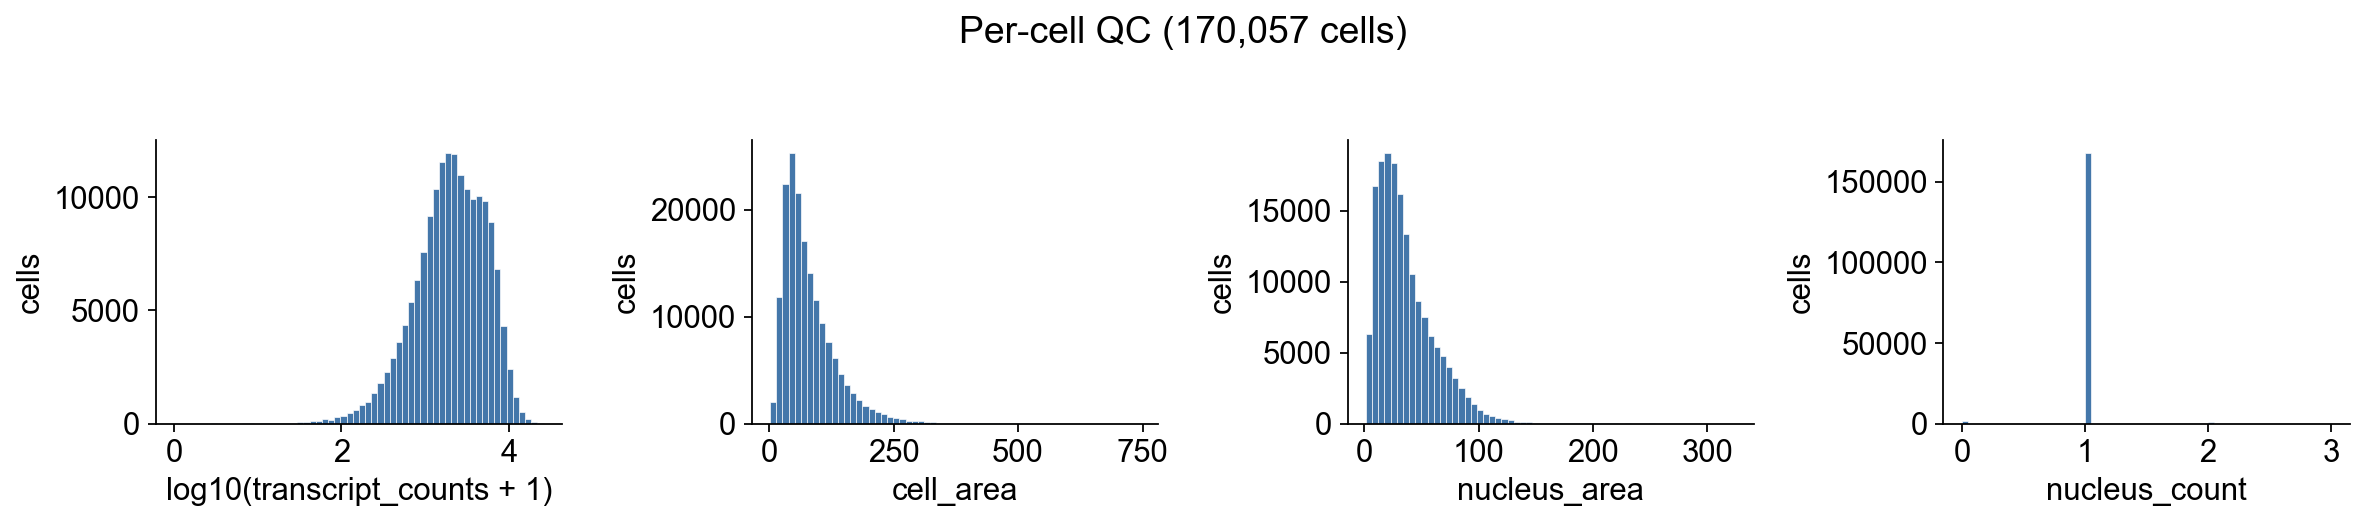

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, (col, log) in zip(axes, [
    ('transcript_counts', True),
    ('cell_area',        False),
    ('nucleus_area',     False),
    ('nucleus_count',    False),
]):
    vals = adata.obs[col].astype(float).to_numpy()
    if log:
        vals = np.log10(vals + 1)
        ax.set_xlabel(f'log10({col} + 1)')
    else:
        ax.set_xlabel(col)
    ax.hist(vals, bins=60, color='#4477aa', edgecolor='white', linewidth=0.3)
    ax.set_ylabel('cells')
    ax.spines[['right', 'top']].set_visible(False)
fig.suptitle(f'Per-cell QC ({adata.n_obs:,} cells)', y=1.02)
fig.tight_layout()
plt.show()


## Inspect the four morphology channels

Atera ships morphology imaging as four separate stain channels rather than a single composite. Each channel is a standalone OME-TIFF pyramid:

| Channel | Stain | Purpose |
|---|---|---|
| `ch0000_dapi.ome.tif` | DAPI | nucleus |
| `ch0001_atp1a1_cd45_e-cadherin.ome.tif` | ATP1A1 + CD45 + E-Cadherin | cell boundary |
| `ch0002_18s.ome.tif` | 18S rRNA | RNA / cell mass |
| `ch0003_alphasma_vimentin.ome.tif` | αSMA + Vimentin | stromal cells |

We re-read the bundle with each channel in turn. `read_atera` only loads the morphology image — the matrix and metadata reuse from `cache_file` are *not* triggered when re-reading directly from the source path with a different `image_key`, but image loading is cheap (~15 s per channel at 2048 px max) so we just call it four times.

In [ ]:
channel_keys = [('dapi',     'DAPI (nucleus)'),
                ('boundary', 'ATP1A1 / CD45 / E-Cadherin (cell boundary)'),
                ('rna',      '18S rRNA'),
                ('stroma',   'αSMA / Vimentin (stroma)')]

channel_imgs = {}
for key, _ in channel_keys:
    a = ov.io.spatial.read_atera(
        ATERA, image_key=key, image_max_dim=2048,
        load_boundaries=False, load_nucleus_boundaries=False,
    )
    channel_imgs[key] = a.uns['spatial'][library_id]['images']['hires']

[Atera] Reading Atera data from: /scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/atera_breast_cancer
[Atera] Loaded morphology channel ch0000_dapi.ome.tif (876, 1454) (downsample 0.0312)
[Atera] Done (n_obs=170057, n_vars=18028, library_id=WTA Breast Cancer (FFPE))
[Atera] Reading Atera data from: /scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/atera_breast_cancer
[Atera] Loaded morphology channel ch0001_atp1a1_cd45_e-cadherin.ome.tif (876, 1454) (downsample 0.0312)
[Atera] Done (n_obs=170057, n_vars=18028, library_id=WTA Breast Cancer (FFPE))
[Atera] Reading Atera data from: /scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/atera_breast_cancer
[Atera] Loaded morphology channel ch0002_18s.ome.tif (876, 1454) (downsample 0.0312)
[Atera] Done (n_obs=170057, n_vars=18028, library_id=WTA Breast Cancer (FFPE))
[Atera] Reading Atera data from: /scratch/users/steorra/analysis/omicverse_dev/omicverse-test/noteboo

[Atera] Loaded morphology channel ch0000_dapi.ome.tif (876, 1454) (downsample 0.0312)
[Atera] Done (n_obs=170057, n_vars=18028, library_id=WTA Breast Cancer (FFPE))
[Atera] Reading Atera data from: /scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/atera_breast_cancer


[Atera] Loaded morphology channel ch0001_atp1a1_cd45_e-cadherin.ome.tif (876, 1454) (downsample 0.0312)
[Atera] Done (n_obs=170057, n_vars=18028, library_id=WTA Breast Cancer (FFPE))
[Atera] Reading Atera data from: /scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/atera_breast_cancer


[Atera] Loaded morphology channel ch0002_18s.ome.tif (876, 1454) (downsample 0.0312)
[Atera] Done (n_obs=170057, n_vars=18028, library_id=WTA Breast Cancer (FFPE))
[Atera] Reading Atera data from: /scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/atera_breast_cancer


[Atera] Loaded morphology channel ch0003_alphasma_vimentin.ome.tif (876, 1454) (downsample 0.0312)
[Atera] Done (n_obs=170057, n_vars=18028, library_id=WTA Breast Cancer (FFPE))


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, (key, title) in zip(axes.flat, channel_keys):
    img = channel_imgs[key]
    # Per-channel 99th-percentile contrast clip — Atera stains have a long tail
    # of bright outliers that flatten the rest of the image if not clipped.
    vmax = np.percentile(img[img > 0], 99) if (img > 0).any() else img.max()
    ax.imshow(img, cmap='gray', vmin=0, vmax=vmax)
    ax.set_title(f'{key}: {title}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Atera morphology focus channels ({img.shape[1]}×{img.shape[0]} px)',
             y=0.94, fontsize=11)
fig.tight_layout()
plt.show()

## Vendor cell-group spatial map

Atera ships a CSV mapping every `cell_id` to a curated cell-type label and a display color (`*_cell_groups.csv`). The 10x team produces these labels with a downstream classifier on top of the segmentation, and they make a useful sanity reference for our own clustering later.

We plot every cell as a tiny dot using its centroid and the vendor color directly.

In [9]:
print(adata.obs['cell_group'].value_counts().head(10))
print()
print(f"{adata.obs['cell_group'].nunique()} groups in total")

cell_group
11q13 Invasive Tumor Cells           64036
CAFs, DCIS Associated                24442
Luminal-like Amorphous DCIS Cells    13028
Basal-like Structured DCIS Cells      8760
Endothelial Cells                     8624
Myoepithelial Cells                   8438
Pericytes                             8087
T Lymphocytes                         8018
CXCL14+ Fibroblasts                   4936
Dendritic Cells                       4008
Name: count, dtype: int64

20 groups in total


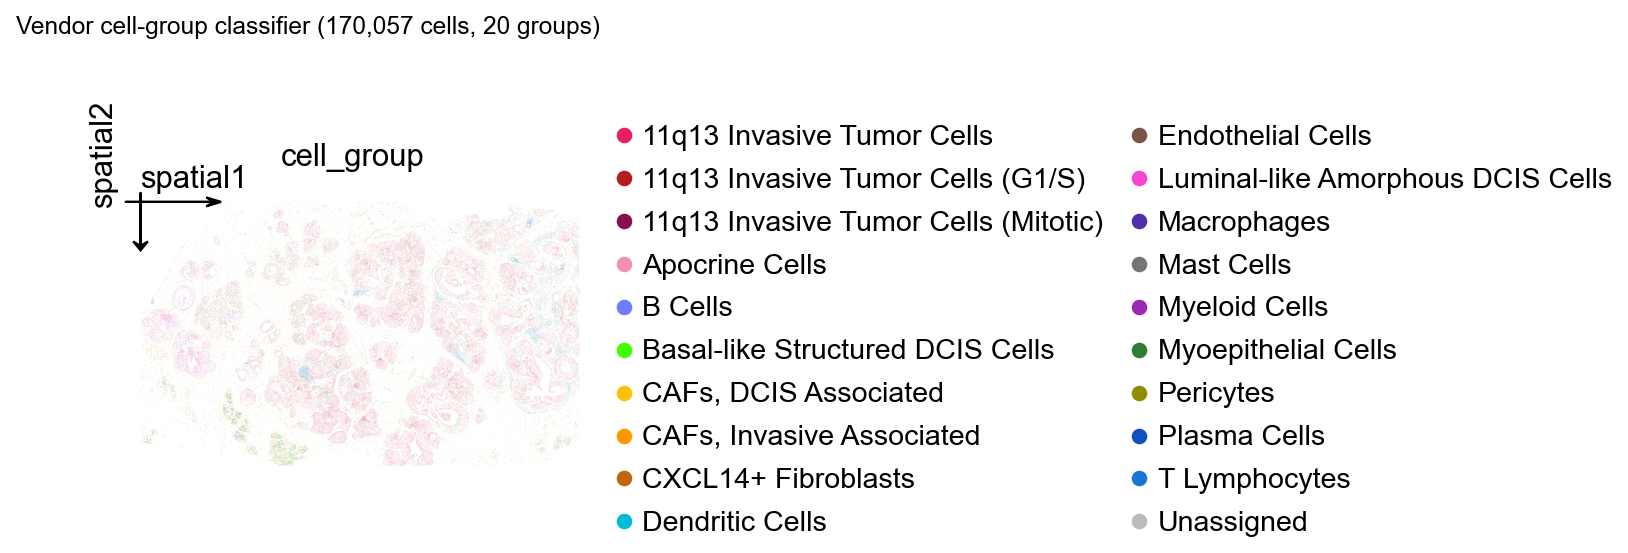

In [10]:
# Wire the vendor display colours into adata.uns so ov.pl.spatial picks
# them up automatically: scanpy/ov plotting reads `uns[<obs_key>_colors]`
# as a list aligned with `obs[<obs_key>].cat.categories`.
_g = adata.obs['cell_group'].astype(object)
_c = adata.obs['cell_group_color'].astype(object)
tab = pd.DataFrame({'cell_group': _g, 'cell_group_color': _c}).dropna().drop_duplicates()
group_to_color = dict(zip(tab['cell_group'], tab['cell_group_color']))
cats = adata.obs['cell_group'].cat.categories
adata.uns['cell_group_colors'] = [group_to_color.get(c, '#bbbbbb') for c in cats]

ov.pl.spatial(
    adata,
    color='cell_group',
    img_key=None,            # drop morphology background — colours speak for themselves
    size=,
    show=False,
)
plt.gcf().suptitle(f'Vendor cell-group classifier ({adata.n_obs:,} cells, '
                   f"{adata.obs['cell_group'].nunique()} groups)",
                   y=1.02, fontsize=11)
plt.show()


## Render cell polygons in a small region

`ov.pl.spatialseg` reads the WKT polygons stored in `obs['geometry']` and renders each cell as its segmentation outline. Plotting all 170k polygons at once would dwarf the visible features, so we subset to a 1 mm × 1 mm window first.

In [11]:
def subset_window(adata, xlim, ylim):
    x, y = adata.obsm['spatial'].T
    mask = (x >= xlim[0]) & (x < xlim[1]) & (y >= ylim[0]) & (y < ylim[1])
    return adata[mask].copy()

# Pick a 1 mm × 1 mm window centred on the densest tumour patch.
# Reuse the same `crop_window` for both `subset_window` and the
# `crop_coord` argument to `ov.pl.spatialseg` — this keeps the
# rendered background image aligned to the polygon extent.
xy = adata.obsm['spatial']
x0, y0 = np.median(xy[:, 0]), np.median(xy[:, 1])
crop_window = (x0 - 500, x0 + 500, y0 - 500, y0 + 500)  # (x0, x1, y0, y1)
bdata = subset_window(adata,
                      xlim=(crop_window[0], crop_window[1]),
                      ylim=(crop_window[2], crop_window[3]))
print(f'Subset window: {bdata.n_obs:,} cells')


Subset window: 3,231 cells


Text(0.5, 0.92, 'Atera cell polygons coloured by vendor cell_group')

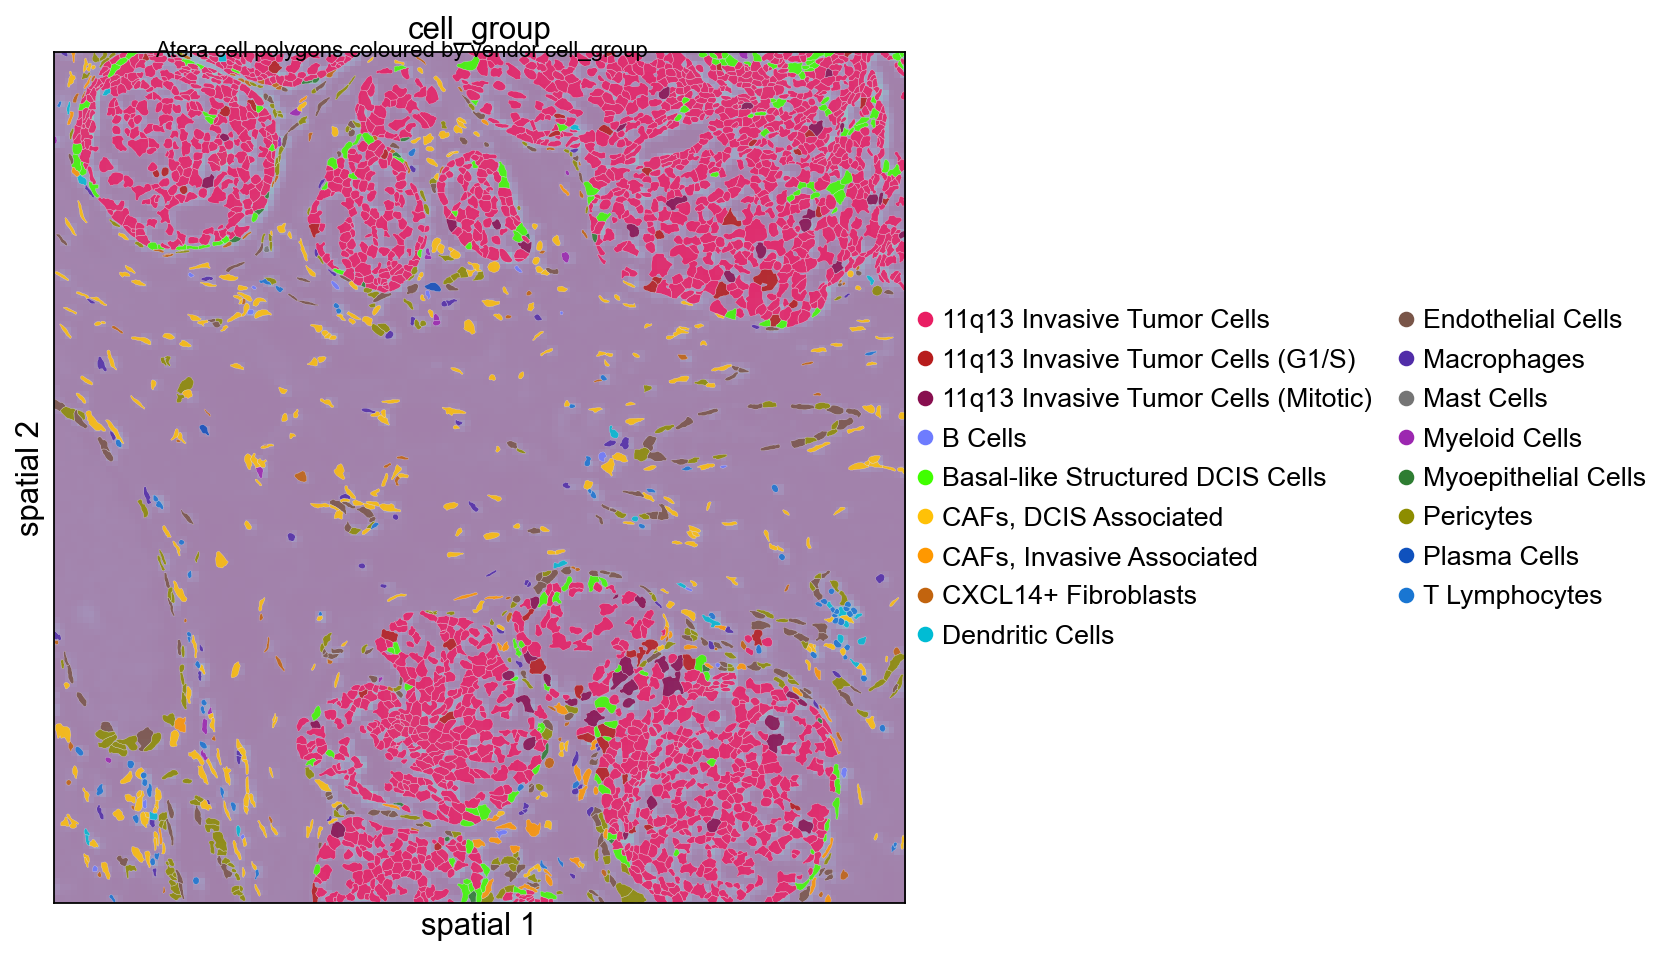

In [12]:
ov.pl.spatialseg(
    bdata,
    color='cell_group',
    crop_coord=crop_window,   # (x0, x1, y0, y1) — crops background to polygon window
    edges_color='white',
    edges_width=0.1,
    figsize=(7, 7),
    alpha=0.85,
    show=False,
)
plt.gcf().suptitle('Atera cell polygons coloured by vendor cell_group',
                   y=0.92, fontsize=10)


## Standard preprocessing

We follow the Visium HD / Xenium recipe: filter very-low-count cells, normalize counts to a fixed total, log-transform, and select highly-variable genes. The Atera matrix is dense enough (median ~2k counts/cell) that a count-based filter is gentle.

In [13]:
adata.layers['counts'] = adata.X.copy()
ov.pp.filter_cells(adata, min_counts=20)
ov.pp.filter_genes(adata, min_cells=10)
ov.pp.normalize_total(adata)
ov.pp.log1p(adata)
print(adata)


🔍 Filtering cells...
   Parameters: min_counts≥20


   ✓ Filtered: 92 cells removed

╭─ SUMMARY: filter_cells ────────────────────────────────────────────╮
│  Duration: 6.392s                                                  │
│  Shape:    170,057 x 18,028 -> 169,965 x 18,028                    │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
🔍 Filtering genes...
   Parameters: min_cells≥10


   ✓ Filtered: 6 genes removed

╭─ SUMMARY: filter_genes ────────────────────────────────────────────╮
│  Duration: 8.701s                                                  │
│  Shape:    169,965 x 18,028 -> 169,965 x 18,022                    │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯

🔍 Count Normalization:
   Target sum: median
   Exclude highly expressed: False



✅ Count Normalization Completed Successfully!
   ✓ Processed: 169,965 cells × 18,022 genes
   ✓ Runtime: 1.02s


AnnData object with n_obs × n_vars = 169965 × 18022
    obs: 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'geometry', 'nucleus_geometry', 'cell_group', 'cell_group_color'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'omicverse_io', 'cell_group_colors', 'history_log', 'log1p'
    obsm: 'spatial'
    layers: 'counts'


In [14]:
ov.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key=None)
adata.raw = adata
adata = adata[:, adata.var['highly_variable']].copy()
print(f'Kept {adata.n_vars} HVGs')


🔍 Highly Variable Genes Selection:
   Method: seurat
   Target genes: 2,000


   ⚠️ Gene indices [ 2347  7356  9855 10554] fell into a single bin: normalized dispersion set to 1
   💡 Consider decreasing `n_bins` to avoid this effect
   📊 Top 2,000 genes correspond to normalized dispersion cutoff: 1.1648

✅ HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 18,022 total (11.1%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'dispersions': Float vector (adata.var)
     • 'dispersions_norm': Float vector (adata.var)

╭─ SUMMARY: highly_variable_genes ───────────────────────────────────╮
│  Duration: 2.9758s                                                 │
│  Shape:    169,965 x 18,022 (Unchanged)                            │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  

Kept 2000 HVGs


In [15]:
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=50)
adata


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 4.3575s                                                 │
│  Shape:    169,965 x 2,000 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ status                                               │
│           │ ✚ status_args                                          │
│                                                                    │
│  ● LAYERS │ ✚ scaled (array, 169965x2000)                          │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🚀 Using GPU to calculate PCA...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA

computing PCA🔍


    with n_comps=50



Using CUDA device: NVIDIA H100 80GB HBM3
✅ Using built-in torch_pca for GPU-accelerated PCA
   🚀 Using torch_pca PCA for CUDA GPU acceleration
   🚀 torch_pca PCA backend: CUDA GPU acceleration (supports sparse matrices)
   📊 PCA input data type: ArrayView, shape: (169965, 2000), dtype: float64
   🔧 solver_used_in_uns (planned): covariance_eigh


   🔧 PCA solver used: covariance_eigh
    finished✅ (6.13s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 6.5831s                                                 │
│  Shape:    169,965 x 2,000 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 169965x50)                             │
│           │ ✚ scaled|original|X_pca (array, 169965x50)             │
│         

AnnData object with n_obs × n_vars = 169965 × 2000
    obs: 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'geometry', 'nucleus_geometry', 'cell_group', 'cell_group_color'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatial', 'omicverse_io', 'cell_group_colors', 'history_log', 'log1p', 'hvg', '_ov_provenance', 'status', 'status_args', 'REFERENCE_MANU', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues'
    obsm: 'spatial', 'X_pca', 'scaled|original|X_pca'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'

## Spatial maps for canonical breast-cancer markers

With the matrix log-normalised, the same `obsm['spatial']` is the natural axis for visualising any gene. We pick four genes that should split cleanly between the cell types in the vendor classifier:

- **`KRT8`**: luminal-epithelial keratin (DCIS / luminal-like cells).
- **`PTPRC`**: CD45 — pan-immune.
- **`COL1A1`**: collagen — CAF / stromal.
- **`PECAM1`**: CD31 — endothelial.

We use `.raw` so we can plot any gene that wasn't selected as HVG.

Available markers: ['KRT8', 'PTPRC', 'COL1A1', 'PECAM1']


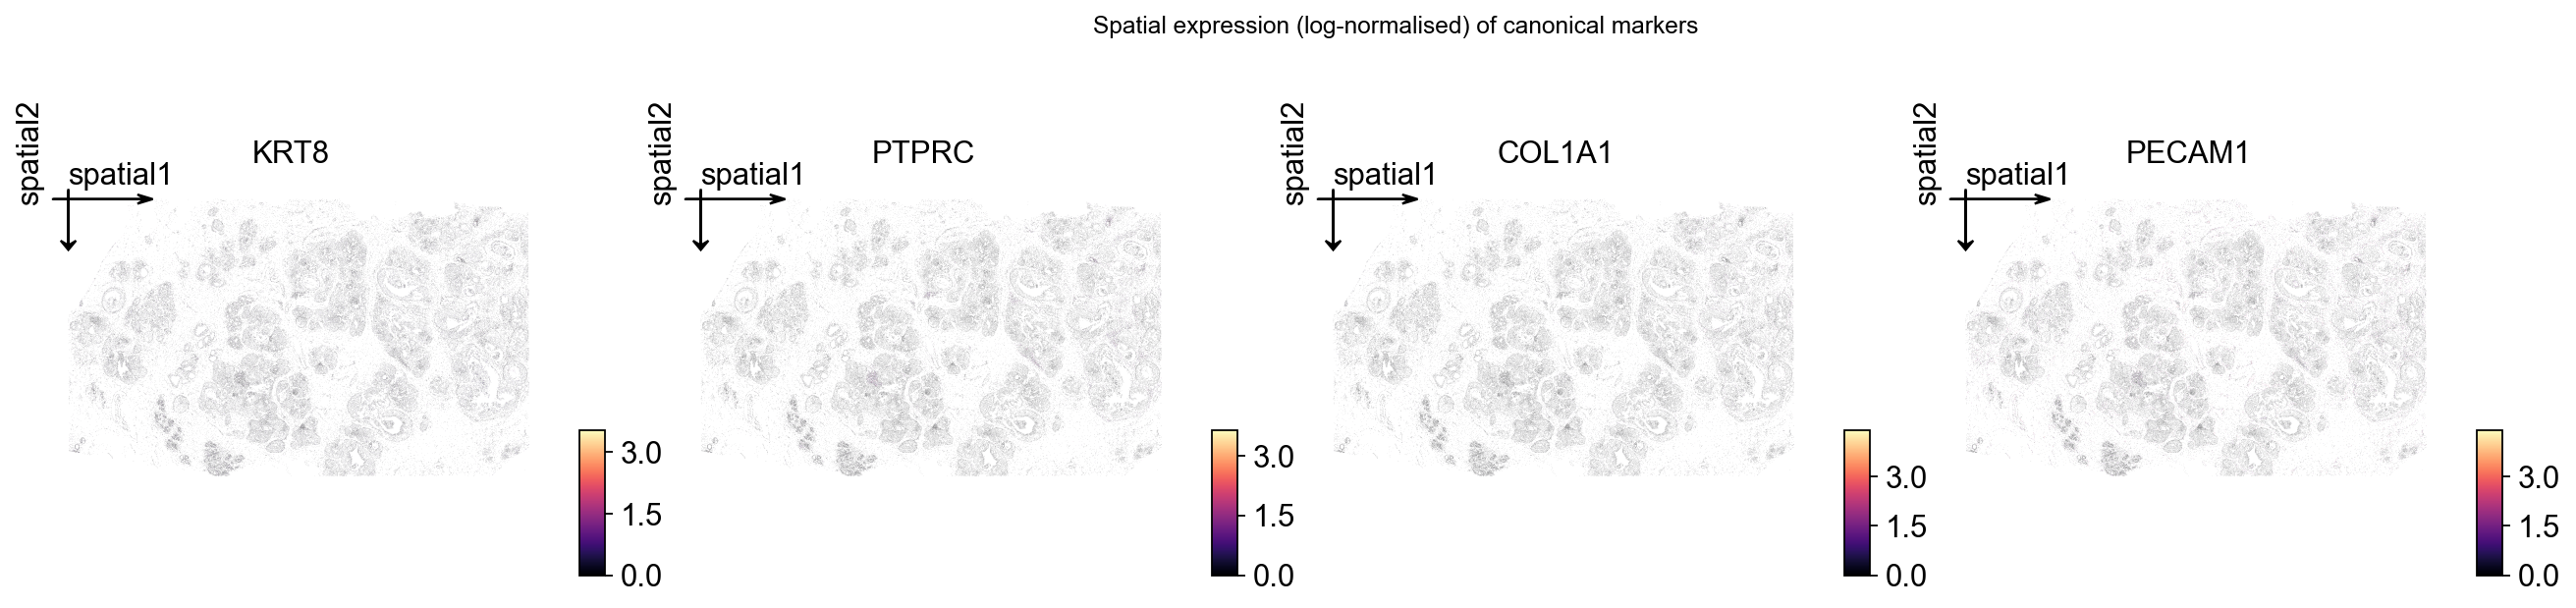

In [16]:
marker_genes = ['KRT8', 'PTPRC', 'COL1A1', 'PECAM1']
available = [g for g in marker_genes if g in adata.raw.var_names]
print('Available markers:', available)

# ov.pl.spatial accepts a list of gene names — it makes one panel per gene.
# We pass `use_raw=True` because the post-HVG `adata` may have dropped some
# of the markers (KRT8 / PTPRC etc. are not always in the top-2000 HVGs).
ov.pl.spatial(
    adata,
    color=available,
    use_raw=True,
    img_key=None,
    size=3,
    cmap='magma',
    show=False,
)
plt.gcf().suptitle('Spatial expression (log-normalised) of canonical markers',
                   y=1.02, fontsize=11)
plt.show()


## Marker spatialseg in the same zoom window

Re-creating the 1 mm × 1 mm subset on the **post-preprocessing** matrix lets us overlay marker expression on top of the cell polygons. `ov.pl.spatialseg` uses the segmentation outlines from `obs['geometry']` rather than centroid points, which gives a cell-shape-aware view.

Subset for spatialseg: 3,230 cells


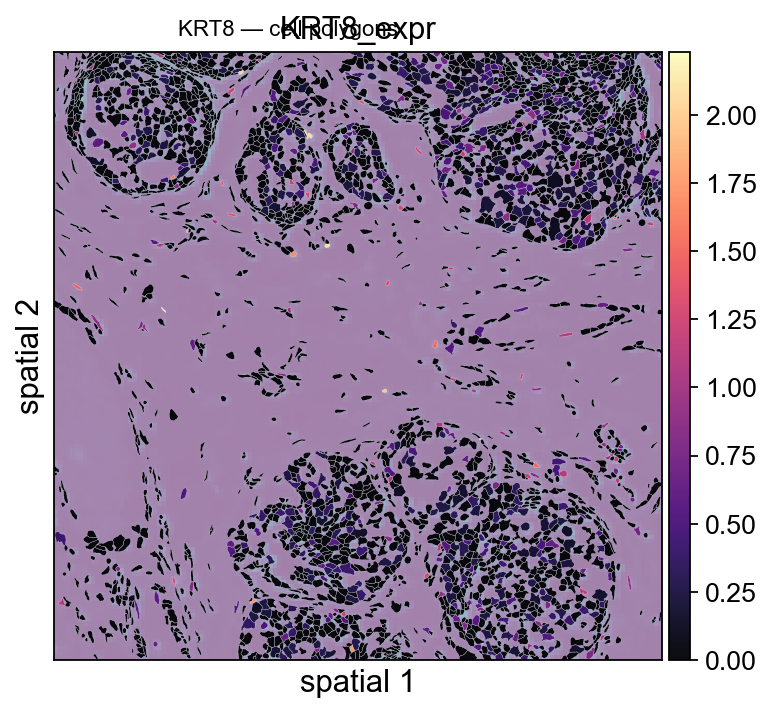

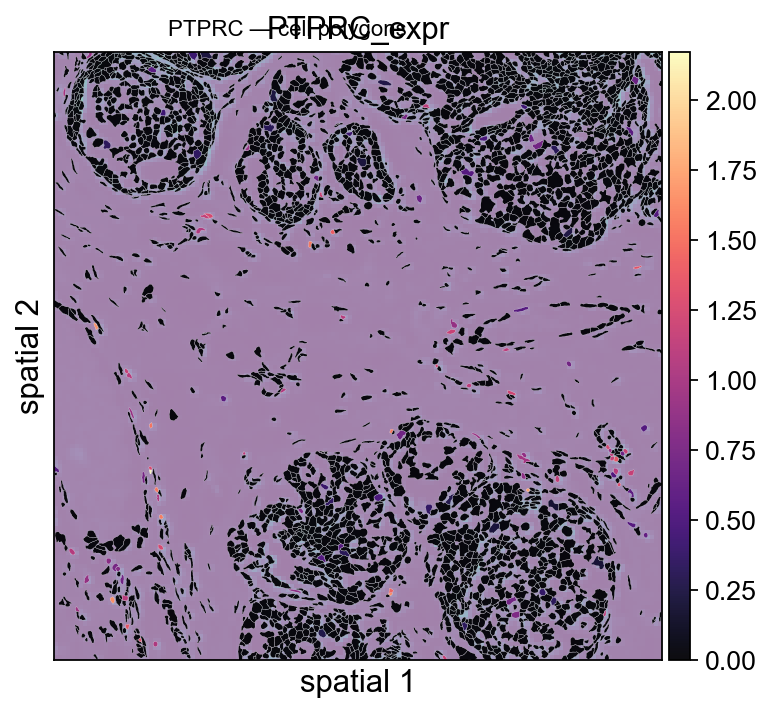

In [17]:
bdata = subset_window(adata,
                      xlim=(crop_window[0], crop_window[1]),
                      ylim=(crop_window[2], crop_window[3]))
print(f'Subset for spatialseg: {bdata.n_obs:,} cells')

# spatialseg pulls colours from `obs[color]` for arbitrary keys; we materialise
# each gene's log-normalised expression into obs so it picks them up cleanly.
raw = adata.raw.to_adata()
raw_b = raw[bdata.obs_names].copy()
for gene in available[:2]:
    bdata.obs[f'{gene}_expr'] = raw_b[:, gene].X.toarray().ravel()

for gene in available[:2]:
    ov.pl.spatialseg(
        bdata,
        color=f'{gene}_expr',
        crop_coord=crop_window,
        edges_color='white',
        edges_width=0.1,
        figsize=(6, 5),
        alpha=0.95,
        cmap='magma',
        show=False,
    )
    plt.gcf().suptitle(f'{gene} — cell polygons', y=0.95, fontsize=10)


## Summary

In this notebook we used `omicverse.io.spatial.read_atera` to:

- load a 170,057-cell × 18,028-gene Atera v1 FFPE breast-cancer dataset into a single `AnnData`,
- inspect Atera's four-channel morphology focus stack (DAPI / boundary / 18S / stroma),
- merge the vendor `cell_groups.csv` classifier directly into `obs`,
- render cell polygons via `ov.pl.spatialseg` for region-of-interest views,
- run a standard normalize → HVG → PCA preprocessing pipeline,
- map canonical breast-cancer markers (KRT8, PTPRC, COL1A1, PECAM1) in physical space.

Atera's `outs/` layout is a strict superset of Xenium's, so any downstream OmicVerse spatial workflow (`ov.space.svg`, `ov.pl.spatial`, neighborhood graphs, leiden clustering, cell-cell communication) works without modification — `read_atera` is the only thing that has to know about the extras (nucleus polygons, channel-named morphology, cell-group CSV, optional H&E + alignment).